# USEPA Embeddedness 2018-2019 Model Building
The purpose of this Jupyter Notebook is to test a few standard models on the EPA 2018-2019 NRSA datasets to predict reach-level gravel streambed embeddedness. We test out a random forest regressor, a gradient boosting regressor, an XGBoost regressor, an adaptive boosting regressor, and an FNN. Prior analysis revealed that boosting models had the most success both with the original Virginia dataset and with the EPA dataset as a whole.

E. Reilly Oare.

In [1]:
# Read in libs
import os 
import warnings 
import pylab 
import json
import pandas as pd 
import numpy as np
import openpyxl 
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl 
import seaborn as sns
from scipy.interpolate import griddata
from sklearn.preprocessing import (
    RobustScaler,
    OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score 
)
from sklearn.metrics import (
    r2_score, 
    mean_squared_error, 
    mean_absolute_error
)
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor 
)
import xgboost as xgb
from xgboost import XGBRegressor
import tensorflow as tf 
from tensorflow.keras import datasets, layers, models
import keras
from keras.models import Sequential, Model 
from keras.layers import (
    Dense, 
    BatchNormalization, 
    Dropout, 
    Input, 
    LeakyReLU, 
    Activation, 
    Add
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam 
from keras import regularizers
from tensorflow.keras.regularizers import l2
import optuna

# Suppress warnings
warnings.filterwarnings("ignore")

## Step 1. Import Dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [3]:
# Read in file
epa_path = os.path.join(BASE_DIR, "data", "model_ready", "usepa_1819_mdl.xlsx")
epa_1819 = pd.read_excel(epa_path).drop(columns = ['Unnamed: 0']).rename(columns = {
    'CTI Wetness Index (QT)':'CTI (QT)',
    '% Evergreen Forest (CBRT)':'% Evergreen Forest (cbrt)',
    '% Crop Land (CBRT)':'% Crop Land (cbrt)',
    '% Deciduous Forest (CBRT)':'% Deciduous Forest (cbrt)',
    '% Hay (CBRT)':'% Hay (cbrt)'
})

In [4]:
# Display dataframe
epa_1819

,Site ID,Unique ID,Latitude,Longitude,Collection Date,Streambed Embeddedness (%),Bankfull Shear Velocity (m/s) (QT),Soil Bulk Density (QT),Avg Watershed Elev (QT),Hydraulic Conductivity (QT),...,Impervious Surface (YJ),Annual Runoff (QT),CTI (QT),Atlantic Plain Division,Interior Highlands Division,Interior Plains Division,Intermontane Plateaus Division,Laurentian Upland Division,Pacific Mountain Division,Rocky Mountain Division
0,NRS18_AR_10190,2012859,34.280395,-94.448356,2018-07-11,28.818182,0.251731,1.219420,-0.347244,-0.460495,...,0.347176,0.864894,-0.414566,False,True,False,False,False,False,False
1,NRS18_MI_10050,2013955,44.183918,-86.171185,2019-07-01,61.250000,-0.580000,0.963957,-0.662260,2.562044,...,0.060981,0.394749,1.363463,False,False,True,False,False,False,False
2,NRS18_NM_10645,2013608,36.597293,-106.063509,2019-04-25,52.545455,1.470157,-0.460495,1.635343,0.483822,...,-0.850664,-0.763158,-0.668770,False,False,False,False,False,False,True
3,NRS18_NE_10011,2013596,40.357431,-98.130438,2018-09-27,92.727273,-0.688473,-0.259817,0.846090,1.363463,...,0.667423,-0.784269,0.592389,False,False,True,False,False,False,False
4,NRS18_AZ_10843,2013644,34.226934,-111.456414,2019-05-10,48.200000,0.592389,0.111083,0.777193,0.155825,...,0.835865,-0.698425,-0.705098,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,NRS18_MT_11470,2014194,46.791930,-107.837106,2019-07-24,46.909091,-0.583089,0.182285,0.633304,1.015026,...,-0.883857,-0.976485,0.243663,False,False,True,False,False,False,False
958,NRS18_WY_11151,2013486,44.575647,-109.105182,2018-09-12,64.727273,0.361130,-1.288101,0.887872,0.939343,...,-0.631708,-0.394749,-0.411725,False,False,False,False,False,False,True
959,NRS18_WY_10029,2013358,44.074227,-105.254597,2018-08-27,98.181818,-1.145937,-1.390385,0.708446,0.540329,...,-0.894331,-2.394362,0.475044,False,False,True,False,False,False,False
960,NRS18_MT_10009,2014323,46.585589,-111.265709,2019-08-06,17.636364,1.203124,-0.024782,1.203124,-1.863194,...,-1.409289,-0.706771,-0.773670,False,False,False,False,False,False,True


## Step 2. Dataset Preparation

### Step 2a. Train Test Split
We will use an 80/20 train/test split since that has worked best with model building in the past for these datasets. However, this was evaluated using trial-and-error. The main issue was not having enough training to reduce the chance of underfitting.

In [5]:
# Define numerical columns
num_cols = ['Latitude', 'Longitude',
           'Bankfull Shear Velocity (m/s) (QT)',
           'Soil Bulk Density (QT)', 'Avg Watershed Elev (QT)',
           'Hydraulic Conductivity (QT)', '% Evergreen Forest (cbrt)',
           '% Crop Land (cbrt)', '% Deciduous Forest (cbrt)', '% Hay (cbrt)',
           'Impervious Surface (YJ)', 'Annual Runoff (QT)',
           'CTI (QT)']

# Define categorical columns
geo_cols = ['Atlantic Plain Division',
            'Interior Highlands Division',
            'Interior Plains Division',
            'Intermontane Plateaus Division',
            'Laurentian Upland Division',
            'Pacific Mountain Division',
            'Rocky Mountain Division']

#### Different Features Available
Above, we have identified the features that we think will work best during model building. However, through trial-and-error, we found a few instances that were *not* successful. In the 'results' folder, there is a 'log' txt file that keeps track of CV metrics for various combinations of model building.

In [6]:
# Split into x and y dataframes
x = epa_1819[num_cols + geo_cols]
y = epa_1819[['Streambed Embeddedness (%)']]

# Check x dataframe
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Latitude                            962 non-null    float64
 1   Longitude                           962 non-null    float64
 2   Bankfull Shear Velocity (m/s) (QT)  962 non-null    float64
 3   Soil Bulk Density (QT)              962 non-null    float64
 4   Avg Watershed Elev (QT)             962 non-null    float64
 5   Hydraulic Conductivity (QT)         962 non-null    float64
 6   % Evergreen Forest (cbrt)           962 non-null    float64
 7   % Crop Land (cbrt)                  962 non-null    float64
 8   % Deciduous Forest (cbrt)           962 non-null    float64
 9   % Hay (cbrt)                        962 non-null    float64
 10  Impervious Surface (YJ)             962 non-null    float64
 11  Annual Runoff (QT)                  962 non-n

In [7]:
# Check y dataframe
y

,Streambed Embeddedness (%)
0,28.818182
1,61.250000
2,52.545455
3,92.727273
4,48.200000
...,...
957,46.909091
958,64.727273
959,98.181818
960,17.636364


In [8]:
# Split x_scld and y using Sklearn
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    random_state = 42,
                                                    test_size = 0.2)

In [9]:
# Check test shape
x_test

,Latitude,Longitude,Bankfull Shear Velocity (m/s) (QT),Soil Bulk Density (QT),Avg Watershed Elev (QT),Hydraulic Conductivity (QT),% Evergreen Forest (cbrt),% Crop Land (cbrt),% Deciduous Forest (cbrt),% Hay (cbrt),Impervious Surface (YJ),Annual Runoff (QT),CTI (QT),Atlantic Plain Division,Interior Highlands Division,Interior Plains Division,Intermontane Plateaus Division,Laurentian Upland Division,Pacific Mountain Division,Rocky Mountain Division
344,32.912152,-110.477373,0.583089,-0.325164,0.665512,0.963957,2.546540,0.156694,0.000000,0.000000,-1.035421,-1.208521,-1.015026,False,False,False,True,False,False,False
381,47.573646,-123.583234,1.121143,-3.078398,0.498536,-1.037103,4.348194,0.000000,0.555682,0.000000,-1.402606,3.078398,-2.350852,False,False,False,False,False,True,False
351,41.988899,-114.995950,0.240976,-1.050596,1.106592,0.053497,0.776528,0.000000,0.820455,0.000000,-0.852343,-1.140922,-0.206208,False,False,False,True,False,False,False
778,43.919047,-71.537224,2.154289,-1.356885,0.222221,-2.734712,4.025665,0.000000,1.563924,0.000000,-1.409289,1.676438,-1.161158,False,False,False,False,False,False,False
277,42.756742,-72.463348,0.972292,-0.247695,-0.927247,-0.951578,2.856397,0.000000,2.805379,1.124062,-0.574726,0.903454,-0.711803,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,40.501014,-100.319590,-1.121143,0.659016,0.406053,0.633304,0.627794,2.933652,0.558860,0.833537,-0.621933,-1.615791,0.074407,False,False,True,False,False,False,False
33,43.840997,-122.820758,1.397275,-1.655541,0.179634,-1.665899,4.386503,0.000000,0.000000,0.000000,-0.801285,2.016914,-0.812974,False,False,False,False,False,True,False
31,35.749309,-97.134335,-0.555483,1.749962,-0.494111,-0.528295,0.665278,1.475567,3.427753,1.428343,-0.430677,-0.363916,0.146591,False,False,True,False,False,False,False
716,42.968172,-84.051734,-0.501492,-0.286894,-0.672036,1.370100,0.756430,2.997743,2.597730,2.332626,1.643299,-0.147910,1.187142,False,False,True,False,False,False,False


In [10]:
# Check training shape
y_train

,Streambed Embeddedness (%)
468,29.090909
857,78.545455
549,48.363636
280,15.454545
109,18.363636
...,...
106,64.545455
270,68.181818
860,65.377358
435,87.927273


### Step 2b. Feature Scaling
Scaling will be applied to numerical columns only (not one-hot encoded columns). The **RobustScaler** was used based on trial-and-error. Technically, you don't need to scale for tree-based models, but we will use it anyways to ensure consistency.

In [11]:
# Initialize scaler and fit on training numerical data
scaler = RobustScaler()
x_train_num = pd.DataFrame(scaler.fit_transform(x_train[num_cols]), 
                           columns=num_cols, 
                           index=x_train.index).astype(float)
x_test_num = pd.DataFrame(scaler.transform(x_test[num_cols]), 
                          columns=num_cols, 
                          index=x_test.index).astype(float)
x_full_num = pd.DataFrame(scaler.transform(x[num_cols]), 
                          columns=num_cols, 
                          index=x.index).astype(float)

# Ensure geo_cols remain boolean
x_train_physio = x_train[geo_cols].astype(bool)
x_test_physio = x_test[geo_cols].astype(bool)
x_full_physio = x[geo_cols].astype(bool)

# Concatenate all columns
x_train_scld = pd.concat([x_train_num, x_train_physio], axis = 1)
x_test_scld = pd.concat([x_test_num, x_test_physio], axis = 1)
x_scld = pd.concat([x_full_num, x_full_physio], axis = 1)

# Validate dtypes
print(f"\n###Training Data Types:###\n {x_train_scld.dtypes}")
print(f"\n###Testing Data Types:###\n {x_test_scld.dtypes}")
print(f"\n###Full Dataset Data Types:###\n {x_scld.dtypes}")


###Training Data Types:###
 Latitude                              float64
Longitude                             float64
Bankfull Shear Velocity (m/s) (QT)    float64
Soil Bulk Density (QT)                float64
Avg Watershed Elev (QT)               float64
Hydraulic Conductivity (QT)           float64
% Evergreen Forest (cbrt)             float64
% Crop Land (cbrt)                    float64
% Deciduous Forest (cbrt)             float64
% Hay (cbrt)                          float64
Impervious Surface (YJ)               float64
Annual Runoff (QT)                    float64
CTI (QT)                              float64
Atlantic Plain Division                  bool
Interior Highlands Division              bool
Interior Plains Division                 bool
Intermontane Plateaus Division           bool
Laurentian Upland Division               bool
Pacific Mountain Division                bool
Rocky Mountain Division                  bool
dtype: object

###Testing Data Types:###
 Latitude 

## Step 3. Model Building
We will be testing multiple models to identify the most successful model given the dataset. The main cross-validation metrics for model selection will include MAE, RMSE, and NSE. We will test:
1. Random Forest Regression
2. Gradient Boosting Regression
3. XGBoost
4. FNN

### Step 3a. Define CV Metrics

In [12]:
# Create global metric dataframe
metric_df = pd.DataFrame(columns=['Model', 'CV RMSE', 'CV MAE', 'CV R2', 'CV NSE'])

# Establish a coordinate df
coords_df = epa_1819.loc[x_scld.index, ['Latitude', 'Longitude']]

# Define function used for metric calculations and plotting
def kfold_model_metrics(model_name, model_builder, X, Y, coords=None, cv=5, save_path_figures=None, save_path_csv=None):
    global metric_df

    # Initialize
    rmse_scores, mae_scores, r2_scores, nse_scores = [], [], [], []
    all_predictions, all_true = [], []
    geo_cv_results = []

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    fig, axes = plt.subplots(cv, 2, figsize=(12, 5 * cv))

    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

        model = model_builder()
        model.fit(X_train, Y_train)
        predictions = model.predict(X_test)

        predictions_np = np.array(predictions).flatten()
        Y_test_np = np.array(Y_test).flatten()
        residuals = Y_test_np - predictions_np

        all_predictions.extend(predictions_np)
        all_true.extend(Y_test_np)

        # Compute metrics
        rmse = np.sqrt(mean_squared_error(Y_test_np, predictions_np))
        mae = mean_absolute_error(Y_test_np, predictions_np)
        r2 = r2_score(Y_test_np, predictions_np)
        # For NSE
        numerator = np.sum((Y_test_np - predictions_np)**2)
        denominator = np.sum((Y_test_np - np.mean(Y_test_np))**2)
        nse = 1 - (numerator / denominator)

        
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)
        nse_scores.append(nse)

        # Store fold-level results
        fold_df = pd.DataFrame({
            'Fold': fold + 1,
            'Observed': Y_test_np,
            'Predicted': predictions_np,
            'Residual': residuals
        }, index=Y_test.index)

        if coords is not None:
            fold_df = fold_df.merge(coords, left_index=True, right_index=True, how='left')

        geo_cv_results.append(fold_df)

        # Plot residuals
        axes[fold, 0].scatter(predictions_np, residuals, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 0].axhline(0, color='black', linestyle='dashed', linewidth=0.75)
        axes[fold, 0].set_xlim([0, 100])
        axes[fold, 0].set_ylim([-50, 50])
        axes[fold, 0].plot([100, 0], [0, 100], color='k', linestyle=':', linewidth=0.5)
        axes[fold, 0].plot([100, 0], [-100, 0], color='k', linestyle=':', linewidth=0.5)
        axes[fold, 0].set_title(f"Fold {fold+1} Residuals", fontname="Arial")
        axes[fold, 0].set_xlabel("Predicted Embeddedness (%)", fontname="Arial")
        axes[fold, 0].set_ylabel("Residuals (%)", fontname="Arial")

        # Plot predicted vs observed
        axes[fold, 1].scatter(Y_test_np, predictions_np, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 1].plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=0.75)
        axes[fold, 1].set_xlim([0, 100])
        axes[fold, 1].set_ylim([0, 100])
        axes[fold, 1].set_title(f"Fold {fold+1} Predicted vs. Observed", fontname="Arial")
        axes[fold, 1].set_xlabel("Observed Embeddedness (%)", fontname="Arial")
        axes[fold, 1].set_ylabel("Predicted Embeddedness (%)", fontname="Arial")

        # Styling
        for ax in axes[fold]:
            ax.grid(False)
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontname("Arial")

    plt.tight_layout()

    if save_path_figures:
        residuals_path = os.path.join(save_path_figures, f"{model_name}_cv_residuals.png")
        plt.savefig(residuals_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Overall Predicted vs True
    plt.figure(figsize=(8, 5))
    plt.scatter(all_true, all_predictions, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], color="black", linestyle="-", linewidth=0.75, label='Perfect Fit (1:1)')
    plt.xlabel("Observed Embeddedness (%)", fontname="Arial", fontsize=14)
    plt.ylabel("Predicted Embeddedness (%)", fontname="Arial", fontsize=14)
    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
        tick.set_fontsize(14)
    plt.tight_layout()
    plt.legend(fontsize=13)
    if save_path_figures:
        overall_pred_path = os.path.join(save_path_figures, f"{model_name}_overall_pred_vs_obs.png")
        plt.savefig(overall_pred_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Overall residuals
    residuals_all = np.array(all_true) - np.array(all_predictions)
    print("The maximum residual is", round(np.abs(residuals_all).max(), 4), "% embeddedness.")
    print("The median residual is", round(np.median(np.abs(residuals_all)), 4), "% embeddedness.")
    print("The minimum residual is", round(np.abs(residuals_all).min(), 4), "% embeddedness.")

    plt.figure(figsize=(8, 5))
    plt.scatter(all_predictions, residuals_all, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.axhline(0, color='k', linestyle='-', linewidth=0.75, label='Perfect Fit (1:1)')
    plt.xlim([0, 100])
    plt.ylim([-50, 50])
    plt.plot([100, 0], [0, 100], color='k', linestyle=':', linewidth=0.5)
    plt.plot([100, 0], [-100, 0], color='k', linestyle=':', linewidth=0.5, label='Max Possible Residual')
    plt.xlabel("Predicted Embeddedness (%)", fontname="Arial", fontsize=14)
    plt.ylabel("Residuals (%)", fontname="Arial", fontsize=14)
    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
        tick.set_fontsize(14)
    plt.tight_layout()
    plt.legend(fontsize=13)
    if save_path_figures:
        overall_resid_path = os.path.join(save_path_figures, f"{model_name}_overall_residuals.png")
        plt.savefig(overall_resid_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Residual threshold info
    residuals_above_20 = residuals_all[np.abs(residuals_all) <= 20]
    percent_above_20 = (len(residuals_above_20) / len(residuals_all)) * 100
    print(f'{percent_above_20}% of residuals are above 20%')

    # Save full GIS-ready results CSV
    all_geo_df = pd.concat(geo_cv_results)
    if save_path_csv:
        results_csv_path = os.path.join(save_path_csv, f"{model_name}_cv_predictions_with_coords.csv")
        all_geo_df.to_csv(results_csv_path, index=True)

    # Update global metrics
    new_row = pd.DataFrame({'Model': [model_name],
                            'CV RMSE': [np.mean(rmse_scores)],
                            'CV MAE': [np.mean(mae_scores)],
                            'CV R2' : [np.mean(r2_scores)],
                            'CV NSE': [np.mean(nse_scores)]})
    metric_df = pd.concat([metric_df, new_row], ignore_index=True)

    return metric_df, rmse_scores, mae_scores, r2_scores, nse_scores

In [13]:
# Separate function for FNN metric calcs and plotting
def manual_fnn_kfold_metrics(fnn_best_params, X, Y, cv=5, epochs=200, validation_split=0.2, patience=15):    
    global metric_df
    
    # Initialize empty lists
    fold_rmse = []
    fold_mae = []
    fold_r2 = []
    fold_nse = []
    
    all_predictions = []
    all_true = []
    
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    fold_num = 1
    fig, axes = plt.subplots(cv, 2, figsize=(12, 5 * cv))
    
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        if hasattr(X, 'iloc'):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        else:
            X_train, X_test = X[train_index], X[test_index]
            
        if hasattr(Y, 'iloc'):
            Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]
        else:
            Y_train, Y_test = Y[train_index], Y[test_index]
        
        # Create a fresh FNN model for each fold
        model = fnn_build_model(fnn_best_params, input_shape=X_train.shape[1])
        
        # Define callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        clr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        
        # Train model for each fold
        model.fit(
            X_train, Y_train,
            epochs=epochs,
            validation_split=validation_split,
            callbacks=[early_stop, clr],
            verbose=2
        )
        
        # Predict on the test fold
        preds = model.predict(X_test).flatten()
        Y_true = np.array(Y_test).flatten()
        
        all_predictions.extend(preds)
        all_true.extend(Y_true)
        
        # Calculate metrics for the fold
        rmse = np.sqrt(mean_squared_error(Y_true, preds))
        mae = mean_absolute_error(Y_true, preds)
        numerator = np.sum((Y_true - preds) **2)
        denominator = np.sum((Y_true - np.mean(Y_true))**2)
        r2 = r2_score(Y_true, preds)
        nse = 1 - (numerator / denominator)
        
        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)
        fold_nse.append(nse)
        
        # Plot diagnostics for each fold
        plt.figure(figsize=(12, 5))
        
        # Residuals plot (Styled)
        axes[fold, 0].scatter(preds, Y_true-preds, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 0].axhline(0, color='black', linestyle='dashed', linewidth=0.75)
        axes[fold, 0].set_xlim([0, 100])
        axes[fold, 0].set_ylim([-50, 50])
        axes[fold, 0].plot([100, 0], [0, 100],
                         color = 'k',
                         linestyle = ':',
                         linewidth = 0.5)
        axes[fold, 0].plot([100, 0], [-100, 0],
                          color = 'k',
                         linestyle = ':',
                         linewidth = 0.5)
        axes[fold, 0].set_title(f"Fold {fold+1} Residuals", fontname="Arial")
        axes[fold, 0].set_xlabel("Predicted Embeddedness (%)", fontname="Arial")
        axes[fold, 0].set_ylabel("Residuals (%)", fontname="Arial")

        # Predicted vs Observed plot (Styled)
        axes[fold, 1].scatter(Y_true, preds, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 1].plot([min(Y_true), max(Y_true)], [min(Y_true), max(Y_true)], color="black", linestyle="--", linewidth=0.75)
        axes[fold, 1].set_xlim([0, 100])
        axes[fold, 1].set_ylim([0, 100])
        axes[fold, 1].set_title(f"Fold {fold+1} Predicted vs. Observed", fontname="Arial")
        axes[fold, 1].set_xlabel("Observed Embeddedness (%)", fontname="Arial")
        axes[fold, 1].set_ylabel("Predicted Embeddedness (%)", fontname="Arial")

        # Apply styling (remove grid, set fonts)
        for ax in axes[fold]:
            ax.grid(False)  # Remove grid
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontname("Arial")
        
        plt.tight_layout()
        # plt.show()
        
        fold_num += 1
    
    # Overall Predicted vs. True across all folds (Styled)
    plt.figure(figsize=(8,5))
    plt.scatter(all_true, all_predictions, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], color="black", linestyle="--", linewidth=0.75, label = 'Perfect Fit (1:1)')
    plt.xlabel("Observed Embeddedness (%)", fontname="Arial")
    plt.ylabel("Predicted Embeddedness (%)", fontname="Arial")

    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)  # Remove grid
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")

    plt.tight_layout()
    plt.legend()

    plt.show()
    
    # Overall Residual Plot
    residuals_all = np.array(all_true) - np.array(all_predictions)
    
    # Print residual statistics
    print("The maximum residual is", round(np.abs(residuals_all).max(), 4), "% embeddedness.")
    print("The median residual is", round(np.median(np.abs(residuals_all)), 4), "% embeddedness.")
    print("The minimum residual is", round(np.abs(residuals_all).min(), 4), "% embeddedness.")
    
    plt.figure(figsize=(8,5))
    plt.scatter(all_predictions, residuals_all, color='darkorange', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.axhline(0, color='k', linestyle='dashed', linewidth=0.75)
    plt.xlim([0, 100])
    plt.ylim([-50, 50])
    plt.plot([100, 0], [0, 100],
                     color = 'k',
                     linestyle = '--',
                     linewidth = 0.5,
            label = 'Perfect Fit (1:1)')
    plt.plot([100, 0], [-100, 0],
                      color = 'k',
                     linestyle = ':',
                     linewidth = 0.5,
            label = 'Maximum Possible Residuals')
    plt.xlabel("Predicted Embeddedness (%)", fontname="Arial")
    plt.ylabel("Residuals (%)", fontname="Arial")

    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)  # Remove grid
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
    plt.tight_layout()
    plt.legend()

    plt.show()
    
    # Aggregate metrics over folds
    avg_rmse = np.mean(fold_rmse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)
    avg_nse = np.mean(fold_nse)
    
    metric_df = pd.DataFrame({
        'CV RMSE': [avg_rmse],
        'CV MAE': [avg_mae],
        'CV R2': [avg_r2],
        'CV NSE': [avg_nse]
    })
    
    return metric_df, fold_rmse, fold_mae, fold_r2, fold_nse

### Step 3b. Model Building

#### Model 1. Random Forest Regressor (RFR)

In [ ]:
############### MANUAL TRAINING OF RF ############
# Uncomment out for manual training

# # Define best hps
# rf_best_params = {
#     'n_estimators': 200, 
#     'max_depth': 25, 
#     'min_samples_split': 8, 
#     'min_samples_leaf': 2, 
#     'max_features': 'log2', 
#     'bootstrap': False
# }

# # Train best model with optimized hyperparameters
# rf_model = RandomForestRegressor(random_state = 42, **rf_best_params, n_jobs = -1)

# # Fit model on training data
# rf_model.fit(x_train_scld, y_train)

In [ ]:
# Define the Optuna objective function
def rf_objective(trial):
    # Define search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step = 50),  
        "max_depth": trial.suggest_int("max_depth", 10, 50, step = 5),  
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),  
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),  
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]), 
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    # Create RF model
    model = RandomForestRegressor(random_state = 42, **params, n_jobs = -1)

    # Perform cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, 
                             x_train_scld, 
                             y_train, 
                             cv = kf, 
                             scoring = "neg_root_mean_squared_error", 
                             n_jobs = -1)

    # Return RMSE
    return np.mean(-scores)  

# Define study
rf_study = optuna.create_study(direction = "minimize", study_name = "RF_Optimization")

# Run optimization
rf_study.optimize(rf_objective, n_trials = 50, n_jobs = -1)

# Print best parameters
print("Best hyperparameters:", rf_study.best_params)

# Extract best hyperparameters
rf_best_params = rf_study.best_params

# Train best model with optimized hyperparameters
rf_model = RandomForestRegressor(random_state = 42, **rf_best_params, n_jobs = -1)

# Fit model on training data
rf_model.fit(x_train_scld, y_train)

In [ ]:
# Use kfold metric function
metric_df, rf_rmse, rf_mae, rf_r2, rf_nse = kfold_model_metrics(
    model_name="RF",
    model_builder=lambda: RandomForestRegressor(
        random_state=42,
        **rf_best_params,
        n_jobs=-1
    ),
    X=x_scld,
    Y=y 
)

#### Model 2. Gradient Boosting Regressor (GBR)

In [ ]:
############### MANUAL TRAINING OF GBR ############
# Uncomment below for training

# gbr_best_params = {"learning_rate":0.007171954175977735, 
#                "max_depth":8,
#                "max_features":'log2',
#                "min_samples_leaf":2,
#                "min_samples_split":3, 
#                "n_estimators":400,
#                "subsample":0.651869159957107}

# # Train best model with optimized hyperparameters
# gbr_model = GradientBoostingRegressor(random_state = 42, **gbr_best_params)

# # Fit model on full training data
# gbr_model.fit(x_train_scld, y_train)

In [ ]:
# Define the Optuna objective function
def gbr_objective(trial):
    # Define search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step = 50),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log = True),
        "max_depth": trial.suggest_int("max_depth", 2, 10), 
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10), 
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5), 
        "subsample": trial.suggest_float("subsample", 0.4, 1.0), 
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }

    # Create GBR model
    model = GradientBoostingRegressor(random_state = 42, **params)

    # Perform CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, x_train_scld, y_train, cv = kf, scoring = "neg_root_mean_squared_error")

    return np.mean(-scores)

# Create an Optuna study
gbr_study = optuna.create_study(direction= "minimize", study_name = "GBR_Optimization") # Minimizing RMSE!

# Run optimization
gbr_study.optimize(gbr_objective, n_trials = 50, n_jobs = -1)

# Extract best hyperparameters
gbr_best_params = gbr_study.best_params

# Train best model with optimized hyperparameters
gbr_model = GradientBoostingRegressor(random_state = 42, **gbr_best_params)

# Fit model on full training data
gbr_model.fit(x_train_scld, y_train)

In [ ]:
# Use kfold metric function
metric_df, gbr_rmse, gbr_mae, gbr_r2, gbr_nse = kfold_model_metrics(
    model_name="GBR",
    model_builder=lambda: GradientBoostingRegressor(random_state=42, **gbr_best_params),
    X=x_scld,
    Y=y,   
    cv=5,
    coords=coords_df,
    save_path_figures=os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures"),
    save_path_csv=os.path.join(BASE_DIR, "usepa_nrsa", "results")
)

##### Optuna Plotting for Successful Algorithm

In [ ]:
# Define best trials from Optuna study
best_trial = gbr_study.best_trial
best_params = best_trial.params  # Best hyperparameter combination
best_value = best_trial.value  # Best RMSE value
trials = gbr_study.trials_dataframe()
trials = trials[trials.state == "COMPLETE"]
trial_numbers = trials.number
objective_values = trials.value
best_trial_number = best_trial.number

# Find position in the dataset
best_x = trial_numbers[trial_numbers == best_trial_number].values[0]
best_y = best_value

In [ ]:
# Extract trial numbers and objective values
trials = gbr_study.trials_dataframe()
trials = trials[trials.state == "COMPLETE"]
trial_numbers = trials.number
objective_values = trials.value

# Find best objective value over time
best_values = np.minimum.accumulate(objective_values)

# Plot objective value vs trial num
fig, ax = plt.subplots(figsize=(6, 4))

# Best value dotted line
ax.plot(trial_numbers, best_values, linestyle="dotted", color="black", linewidth=1, label="Best Value", zorder=2)

# Scatter plot for trials
sc = ax.scatter(
    trial_numbers, objective_values,
    color='darkorange', edgecolors='black', facecolors='darkorange', s=25,
    linewidths=0.5, alpha=0.7, label="Trial Objective Values",
    zorder=3
)
# Highlight the best trial
ax.scatter(best_x, best_y, color="white", edgecolors="black", s=150, marker="*", linewidths=1.5, label="Best Trial")

# Customizing aesthetics
ax.set_xlabel("Trial", fontsize=12, fontname="Arial", color="black")
ax.set_ylabel("Negative RMSE", fontsize=12, fontname="Arial", color="black")
ax.set_title("Optimization History of GBR", fontsize=14, fontname="Arial", color="black")

# Show legend
ax.legend(frameon=False, loc="best")
plt.tight_layout()

# Save for paper
opt_hist_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_optimization_history.png")
plt.savefig(opt_hist_path, dpi = 300)

# Display plot
plt.show()

In [ ]:
# Get hyperparameter importance
importance = optuna.importance.get_param_importances(gbr_study)
params = list(importance.keys())
values = list(importance.values())

# Sort by importance (descending)
params, values = zip(*sorted(zip(params, values), key=lambda x: x[1], reverse=False))

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Horizontal bar plot
bars = ax.barh(params, values, color="darkorange", edgecolor="black", linewidth=0.7, alpha=0.7)

# Customizing aesthetics
ax.set_facecolor("white")
ax.set_xlabel("Importance", fontsize=12, fontname="Arial", color="black")
ax.set_ylabel("Hyperparameter", fontsize=12, fontname="Arial", color="black")
ax.set_title("Hyperparameter Importance for GBR", fontsize=14, fontname="Arial", color="black")

# Show exact importance values on bars
for bar, value in zip(bars, values):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}", ha="left", va="center", fontsize=10, fontname="Arial", color="black"
    )
plt.tight_layout()

# Save for paper
opt_imp_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_optimization_importance.png")
plt.savefig(opt_imp_path, dpi = 300)

# Show the plot
plt.show()

In [ ]:
# Find best trial's hyperparameters (top importances)
best_trial = gbr_study.best_trial
best_x = best_trial.params["learning_rate"]
best_y = best_trial.params["n_estimators"]
best_value = best_trial.value  # Best RMSE

In [ ]:
# Select hyperparameters to visualize
param_x_col = "params_learning_rate"
param_y_col = "params_n_estimators"

# Define x and y values
x = trials[param_x_col]
y = trials[param_y_col]
z = trials["value"]  # Objective function value

# Create a figure
fig, ax = plt.subplots(figsize=(6, 4))

# Create a grid for contouring
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the objective values for contour plotting
grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

# Plot filled contours
contour = ax.contourf(grid_x, grid_y, grid_z, cmap="Oranges", alpha=0.7)
contour_lines = ax.contour(grid_x, grid_y, grid_z, colors="black", linewidths=0.5)

# Add color bar
cbar = plt.colorbar(contour)
cbar.set_label("Negative RMSE", fontsize=12, fontname="Arial", color="black")

# Scatter plot of actual trials
ax.scatter(x, y, color="darkorange", edgecolors="black", s=25, linewidths=0.5, alpha=0.7, label="Trials")

# Highlight the best trial
ax.scatter(best_x, best_y, color="white", edgecolors="black", s=150, marker="*", linewidths=1.5, label="Best Trial")

# Customizing aesthetics
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Learning Rate", fontsize=12, fontname="Arial", color="black")
ax.set_ylabel("Number of Estimators", fontsize=12, fontname="Arial", color="black")
ax.set_title("Contour Plot of Learning Rate vs N Estimators", fontsize=14, fontname="Arial", color="black")

# Show legend
ax.legend(frameon=False)

# Save for paper
opt_contour_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_optimization_countour_plot.png")
plt.savefig(opt_contour_path, dpi = 300)

# Show the plot
plt.show()

#### Model 3. XGBoost

In [ ]:
############# MANUAL TRAINING OF XGBOOST ############
# Uncomment below for training

# # Define best hps
# xgb_best_params = {
#     'n_estimators': 503, 
#     'learning_rate': 0.01610828468409669, 
#     'max_depth': 4, 
#     'subsample': 0.52173049518222, 
#     'colsample_bytree': 0.5828604193210032, 
#     'min_child_weight': 3, 
#     'reg_alpha': 0.03626374787052683, 
#     'reg_lambda': 0.9800260372662566, 
#     'gamma': 4.465706379070049, 
#     'scale_pos_weight': 1.0386877086310855
# }

# # Train best model
# xgb_model = xgb.XGBRegressor(
#     **xgb_best_params,
#     random_state = 42,
#     tree_method = "hist",
#     eval_metric = "rmse"
# )

# # Fit model on training data
# xgb_model.fit(x_train_scld, y_train)

In [ ]:
# Define the objective function for Optuna
def xgb_objective(trial):
    # Define search  space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "subsample": trial.suggest_float("subsample", 0.4, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 0.1), 
        "reg_lambda": trial.suggest_float("reg_lambda", 0.8, 1.5),  
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.2),  
    }
    
    # Create model
    model = xgb.XGBRegressor(
        **params,
        random_state = 42,
        tree_method = "hist",
        eval_metric = "rmse",
        n_jobs = -1
    )
    
    # Perform CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, 
                             x_train_scld, 
                             y_train, 
                             cv = kf, 
                             scoring = "neg_root_mean_squared_error")
    
    return np.mean(-scores) # Minimize RMSE

# Create Optuna study
xgb_study = optuna.create_study(direction = "minimize", study_name = "XGB_Optimization")  # We want to minimize RMSE

# Run optimization
xgb_study.optimize(xgb_objective, n_trials = 50, n_jobs = -1)

# Print best parameters
print("Best hyperparameters:", xgb_study.best_params)
print("Best RMSE:", xgb_study.best_value)
                            
# Extract best hyperparameters
xgb_best_params = xgb_study.best_params

# Train best model! Woohoo!
xgb_model = xgb.XGBRegressor(
    **xgb_best_params,
    random_state = 42,
    tree_method = "hist",
    eval_metric = "rmse"
)

# Fit model on training data
xgb_model.fit(x_train_scld, y_train)

In [ ]:
metric_df, xgb_rmse, xgb_mae, xgb_r2, xgb_nse = kfold_model_metrics(
    model_name="XGBoost",
    model_builder=lambda: xgb.XGBRegressor(
        **xgb_best_params,
        random_state=42,
        tree_method="hist",
        eval_metric="rmse"
    ),
    X=x_scld,
    Y=y
)
print(metric_df)

#### Model 4. FNN

In [ ]:
######## MANUAL TRAINING OF FNN ############
# Uncomment below for training

# # Define best hps
# fnn_best_params = {
#     'learning_rate': 0.00044846566233004893, 
#     'batch_size': 32, 
#     'units_0': 128, 
#     'dropout_0': 0.2
# }

# # Build final model using extracted parameters
# fnn_model = fnn_build_model(fnn_best_params, input_shape=x_train_scld.shape[1])

# # Define learning rate scheduler
# clr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=5,
#     min_lr=1e-6
# )

# # Train model
# history = fnn_model.fit(
#     x_train_scld, 
#     y_train, 
#     epochs=200,  
#     validation_split=0.2,  
#     callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), clr],
#     verbose=2
# )

In [14]:
# Define FNN model building function
def fnn_build_model(best_params, input_shape):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    
    # Single hidden layer
    model.add(Dense(units=best_params["units_0"], activation='relu', kernel_regularizer=l2(0.02)))
    model.add(BatchNormalization())
    model.add(Dropout(rate=best_params["dropout_0"]))
    
    # Output layer
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=Adam(learning_rate=best_params["learning_rate"]),
        loss="mean_squared_error"
    )
    
    return model

In [15]:
# Define FNN objective function
def fnn_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64]),
        "units_0": trial.suggest_int("units_0", 32, 256, step=32),
        "dropout_0": trial.suggest_float("dropout_0", 0.2, 0.5, step=0.05)
    }

    # Manual 5-fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_index, val_index in kf.split(x_train_scld):
        X_train_fold, X_val_fold = x_train_scld.iloc[train_index], x_train_scld.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Build and train model
        model = fnn_build_model(params, input_shape=x_train_scld.shape[1])
        model.fit(
            X_train_fold, y_train_fold,
            epochs=100,
            batch_size=params["batch_size"],
            validation_data=(X_val_fold, y_val_fold),
            verbose=0
        )

        # Evaluate model
        y_pred = model.predict(X_val_fold)
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))  # RMSE
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

In [16]:
# Create Optuna study for FNN
fnn_study = optuna.create_study(direction="minimize", study_name="FNN_Optimized")
fnn_study.optimize(fnn_objective, n_trials=50, n_jobs=-1)

[I 2025-08-02 11:55:40,069] A new study created in memory with name: FNN_Optimized


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step
1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 565ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002545BE64720> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 602ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step
5

[I 2025-08-02 12:10:15,138] Trial 6 finished with value: 62.192484491160165 and parameters: {'learning_rate': 0.00012529860753840376, 'batch_size': 64, 'units_0': 32, 'dropout_0': 0.45}. Best is trial 6 with value: 62.192484491160165.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


[I 2025-08-02 12:10:48,270] Trial 11 finished with value: 64.22743002313831 and parameters: {'learning_rate': 1.1904933583270134e-05, 'batch_size': 64, 'units_0': 32, 'dropout_0': 0.35000000000000003}. Best is trial 6 with value: 62.192484491160165.


...

[I 2025-08-02 12:36:05,891] Trial 47 finished with value: 18.322315632240283 and parameters: {'learning_rate': 0.0004769735354018652, 'batch_size': 64, 'units_0': 256, 'dropout_0': 0.25}. Best is trial 12 with value: 17.732519113956197.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


[I 2025-08-02 12:36:09,347] Trial 48 finished with value: 18.172147498517838 and parameters: {'learning_rate': 0.0004992483960810081, 'batch_size': 64, 'units_0': 256, 'dropout_0': 0.25}. Best is trial 12 with value: 17.732519113956197.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


[I 2025-08-02 12:36:21,050] Trial 49 finished with value: 39.697719360484705 and parameters: {'learning_rate': 0.000251749686982717, 'batch_size': 64, 'units_0': 256, 'dropout_0': 0.25}. Best is trial 12 with value: 17.732519113956197.


In [17]:
# Extract best parameters
fnn_best_params = fnn_study.best_params

# Print results
print(fnn_best_params)

{'learning_rate': 0.00044846566233004893, 'batch_size': 32, 'units_0': 128, 'dropout_0': 0.2}


In [18]:
# Build final model using extracted parameters
fnn_model = fnn_build_model(fnn_best_params, input_shape=x_train_scld.shape[1])

# Define learning rate scheduler
clr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Train model
history = fnn_model.fit(
    x_train_scld, 
    y_train, 
    epochs=200,  
    validation_split=0.2,  
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), clr],
    verbose=2
)

Epoch 1/200
20/20 - 3s - 151ms/step - loss: 4177.6821 - val_loss: 4001.0520 - learning_rate: 4.4847e-04
Epoch 2/200
20/20 - 0s - 17ms/step - loss: 4117.8110 - val_loss: 3974.2163 - learning_rate: 4.4847e-04
Epoch 3/200
20/20 - 1s - 33ms/step - loss: 4082.6123 - val_loss: 3944.8835 - learning_rate: 4.4847e-04
Epoch 4/200
20/20 - 0s - 15ms/step - loss: 4035.6682 - val_loss: 3913.8394 - learning_rate: 4.4847e-04
Epoch 5/200
20/20 - 0s - 16ms/step - loss: 3991.7378 - val_loss: 3879.0305 - learning_rate: 4.4847e-04
Epoch 6/200
20/20 - 0s - 17ms/step - loss: 3954.5293 - val_loss: 3841.5173 - learning_rate: 4.4847e-04
Epoch 7/200
20/20 - 0s - 22ms/step - loss: 3907.2715 - val_loss: 3799.8767 - learning_rate: 4.4847e-04
Epoch 8/200
20/20 - 0s - 14ms/step - loss: 3865.6228 - val_loss: 3754.9285 - learning_rate: 4.4847e-04
Epoch 9/200
20/20 - 0s - 17ms/step - loss: 3817.0093 - val_loss: 3704.1838 - learning_rate: 4.4847e-04
Epoch 10/200
20/20 - 1s - 31ms/step - loss: 3763.1082 - val_loss: 3650.2

Epoch 1/200
16/16 - 3s - 174ms/step - loss: 4220.3672 - val_loss: 4146.9043 - learning_rate: 4.4847e-04
Epoch 2/200
16/16 - 0s - 22ms/step - loss: 4182.3862 - val_loss: 4125.0977 - learning_rate: 4.4847e-04
Epoch 3/200
16/16 - 0s - 18ms/step - loss: 4146.1528 - val_loss: 4101.4136 - learning_rate: 4.4847e-04
Epoch 4/200
16/16 - 0s - 21ms/step - loss: 4108.4409 - val_loss: 4077.1340 - learning_rate: 4.4847e-04
Epoch 5/200
16/16 - 0s - 21ms/step - loss: 4067.4275 - val_loss: 4050.5935 - learning_rate: 4.4847e-04
Epoch 6/200
16/16 - 0s - 21ms/step - loss: 4033.1914 - val_loss: 4022.9290 - learning_rate: 4.4847e-04
Epoch 7/200
16/16 - 0s - 21ms/step - loss: 3998.9170 - val_loss: 3991.7927 - learning_rate: 4.4847e-04
Epoch 8/200
16/16 - 0s - 21ms/step - loss: 3966.4641 - val_loss: 3958.1628 - learning_rate: 4.4847e-04
Epoch 9/200
16/16 - 0s - 20ms/step - loss: 3936.1973 - val_loss: 3922.2598 - learning_rate: 4.4847e-04
Epoch 10/200
16/16 - 0s - 18ms/step - loss: 3897.7471 - val_loss: 3884.7

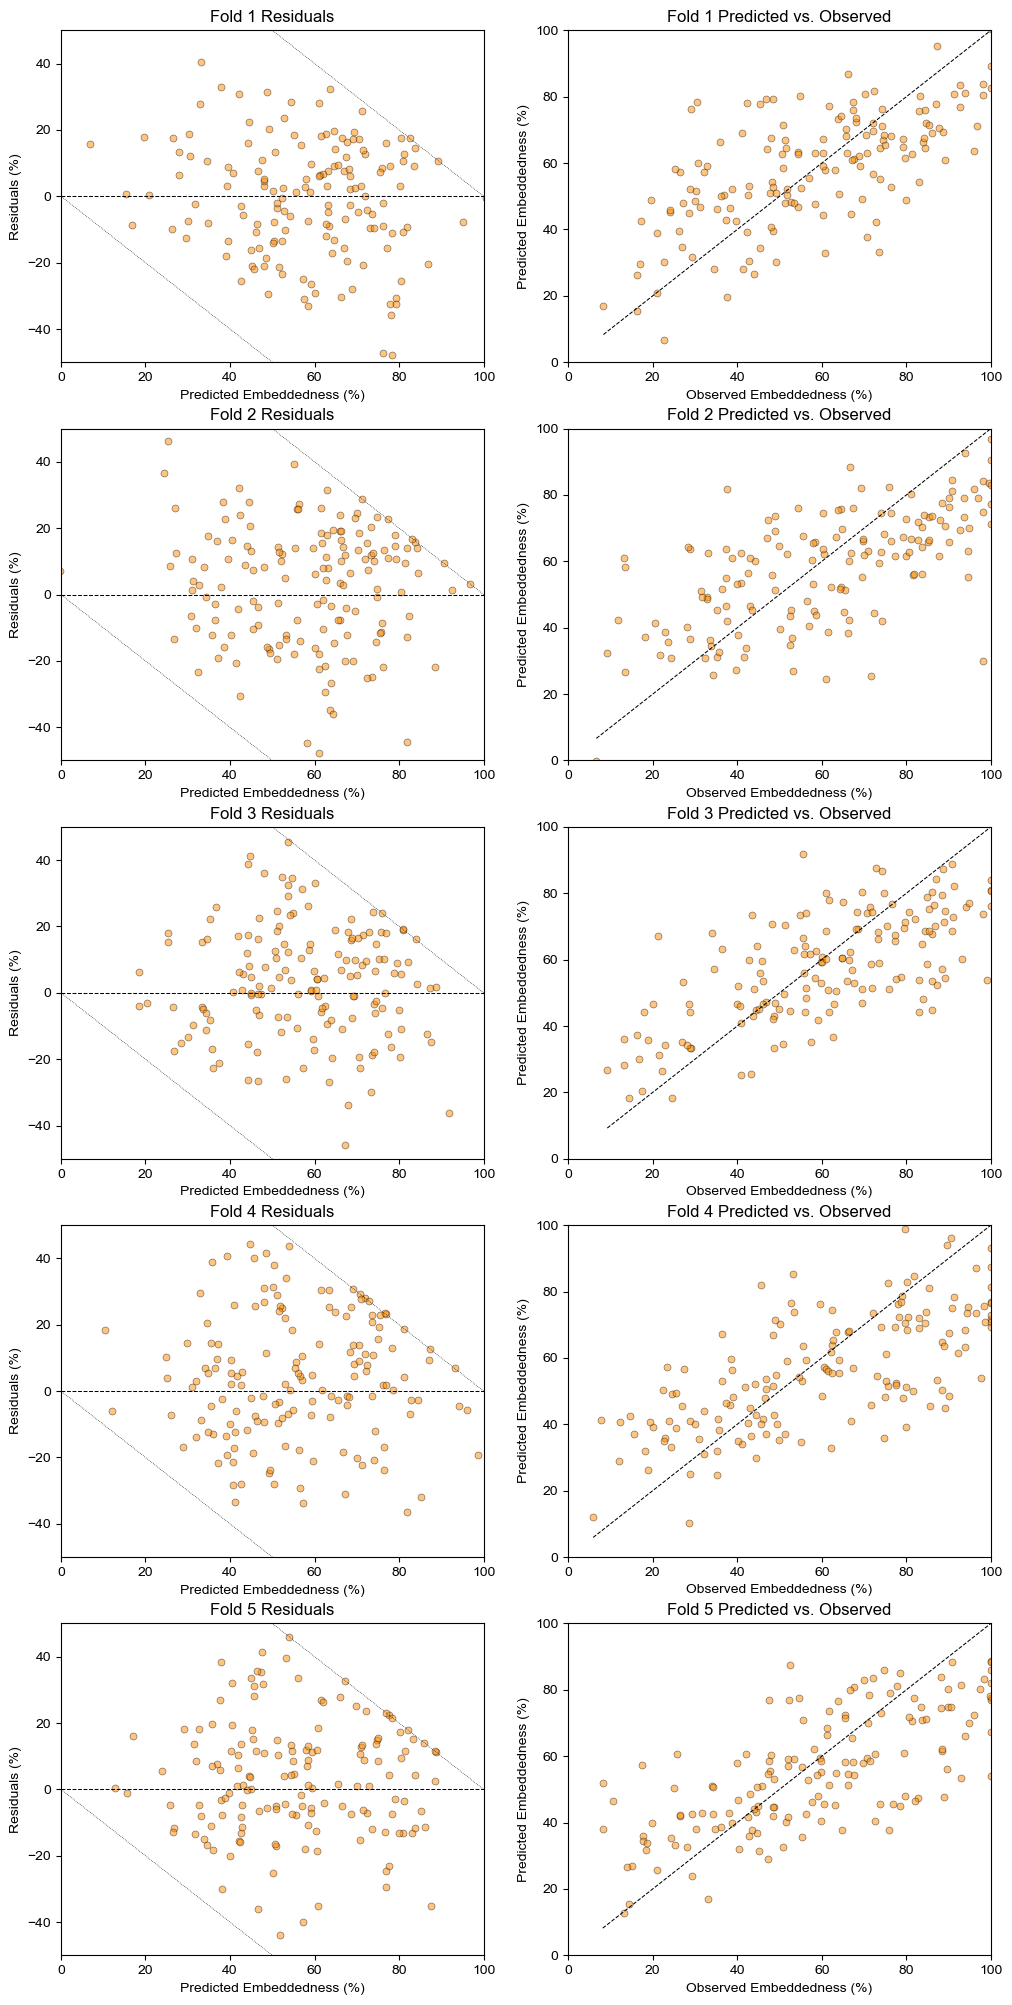

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

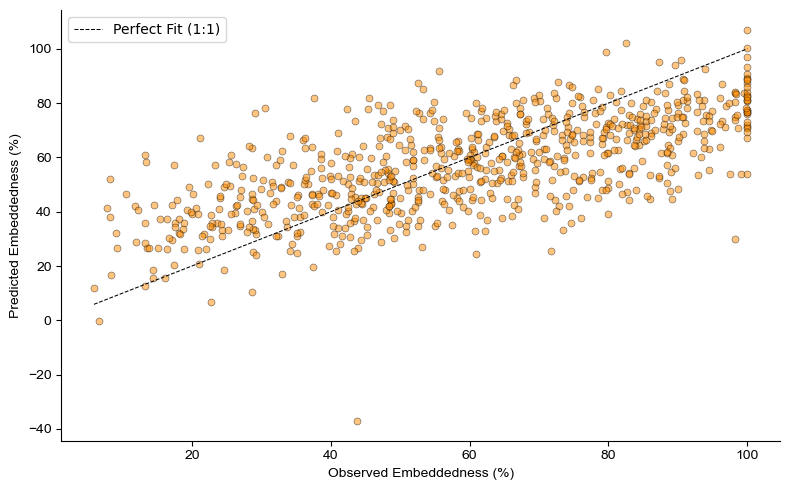

The maximum residual is 80.9349 % embeddedness.
The median residual is 12.554 % embeddedness.
The minimum residual is 0.0445 % embeddedness.


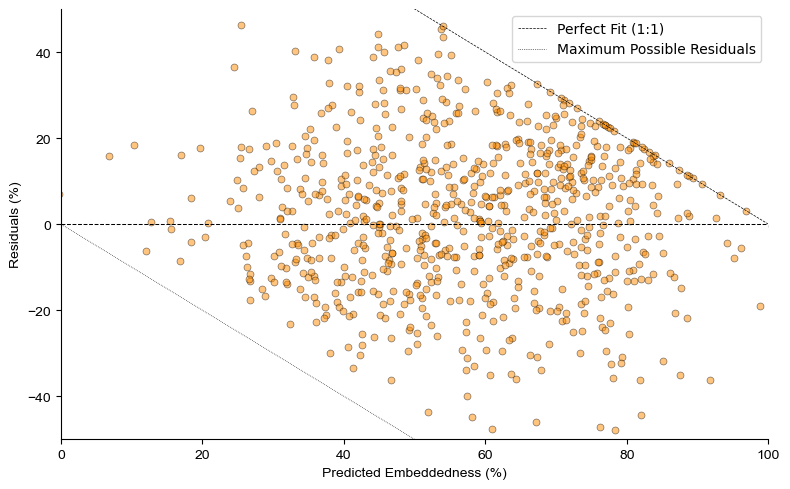

In [19]:
# Use manual kfold function
metric_df, fnn_rmse, fnn_mae, fnn_r2, fnn_nse = manual_fnn_kfold_metrics(
    fnn_best_params, # from Optuna
    X=x_train_scld,
    Y=y_train,
    cv=5,
    epochs=200,
    validation_split=0.2,
    patience=15
)

## Step 4. Model Comparison
Based on the CV metrics, it appears that our models are not performing as well as hoped, but we are likely being held back by the data set. We will stop with the current model.

In [20]:
# Display dataframe with CV metrics
print(metric_df)

     CV RMSE     CV MAE     CV R2    CV NSE
0  18.100759  14.604296  0.426883  0.426883


Based on the above plots and CV metrics, we will move forward with the **GBR Model.**

## Step 5. Export Model & Results

In [ ]:
# Export metric dataframe (model comparison visualization)
metric_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "usepa_1819_metrics.xlsx")
metric_df.to_excel(metric_path)

In [ ]:
# Save the trained model and train_test_split for later use
mdl_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "trained_gbr_model.pkl")
train_test_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "train_test_sets.pkl")

# Save sets/model
joblib.dump(gbr_model, mdl_path)
print('GBR model saved.')
joblib.dump((x_train_scld, x_test_scld, y_train, y_test), train_test_path)
print('Training and testing sets saved.')